# EDA de PM2.5 y meteorología — Entrega 1

## 1. Objetivo

Este notebook sigue el orden trabajado en los ejemplos del curso: cargar los datos, entender qué representan filas y columnas, revisar `head`, `shape`, `dtypes`, `info` y `describe`, evaluar calidad y explicar cada resultado. Respalda la caracterización y los insights exigidos en la Entrega 1 para la pregunta de investigación vigente: **predecir, con un día de anticipación, la concentración media diaria de PM2.5 por estación en el Valle de Aburrá a partir del historial del contaminante y variables temporales, y en qué medida las variables meteorológicas observadas de SIATA mejoran esa predicción frente a un pronóstico de persistencia**. Aquí no se entrenan modelos.


## 2. Fuente y reproducibilidad

Los archivos de PM2.5 provienen del dataset oficial **Histórico de Material Particulado - PM2.5** de SIATA, DOI `10.83041/AUWZWT`, versión 4.0 consultada el 14 de septiembre de 2026. Se descargan con `python scripts/download_pm25_dataset.py --all`; los datos crudos no se versionan en Git. El loader utilizado abajo solo automatiza tres tareas repetitivas: detectar el separador, convertir `fecha_hora` y comprobar que las mediciones sean numéricas.

Los datos meteorológicos provienen de la colección **Meteorológica** de SIATA, donde cada estación es un dataset independiente con registros minutales. Se descargan con `python scripts/download_meteo_dataset.py` y se agregan a resolución horaria con `python scripts/build_meteo_hourly.py`, que aplica la bandera de calidad de SIATA. La asignación de una estación meteorológica a cada estación de PM2.5 está en `docs/station_matching.md`.

## 3. Carga de datos

Se importan únicamente las librerías necesarias y se localizan los archivos desde la raíz del proyecto para que el notebook funcione tanto desde Jupyter como desde el repositorio.


In [1]:
from collections import Counter
from pathlib import Path
import io
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.data import load_pm25_files, read_pm25_file
from src.data.stations import PM25_TO_METEO

DATA_DIR = PROJECT_ROOT / 'data' / 'raw' / 'pm25'
NETWORK_DIR = PROJECT_ROOT / 'data' / 'raw' / 'network'
METEO_HOURLY = PROJECT_ROOT / 'data' / 'interim' / 'meteo_hourly.csv'
files = sorted(DATA_DIR.glob('Estaciones_PM2.5_*.tab'))
len(files), files[0].name, files[-1].name


(162, 'Estaciones_PM2.5_2013_01.tab', 'Estaciones_PM2.5_2026_06.tab')

## 4. Estructura de un archivo mensual

Primero se examina enero de 2013. El loader detecta codificación y delimitador; no se supone que `.tab` implique tabuladores. El archivo original de este mes está separado por comas.

In [2]:
sample = read_pm25_file(files[0])
display(sample.head())
display(sample.tail())
print('shape:', sample.shape)
print('columns:', sample.columns.tolist())
print('dtypes:')
display(sample.dtypes.to_frame('dtype'))
buffer = io.StringIO()
sample.info(buf=buffer)
print(buffer.getvalue())
display(sample.describe(include='all'))

,fecha_hora,MED-UNNV,CEN-TRAF,ITA-CJUS,ITA-CONC,CAL-LASA
0,2013-01-01 00:00:00,69.0,77.0,NaN,121.0,NaN
1,2013-01-01 01:00:00,80.0,78.0,NaN,62.0,NaN
2,2013-01-01 02:00:00,55.0,59.0,NaN,86.0,NaN
3,2013-01-01 03:00:00,50.0,39.0,NaN,74.0,NaN
4,2013-01-01 04:00:00,34.0,34.0,NaN,44.0,NaN


,fecha_hora,MED-UNNV,CEN-TRAF,ITA-CJUS,ITA-CONC,CAL-LASA
739,2013-01-31 19:00:00,37.0,48.0,NaN,31.0,29.0
740,2013-01-31 20:00:00,35.0,40.0,NaN,28.0,38.0
741,2013-01-31 21:00:00,36.0,32.0,NaN,24.0,33.0
742,2013-01-31 22:00:00,31.0,34.0,NaN,22.0,39.0
743,2013-01-31 23:00:00,31.0,49.0,NaN,33.0,31.0


shape: (744, 6)
columns: ['fecha_hora', 'MED-UNNV', 'CEN-TRAF', 'ITA-CJUS', 'ITA-CONC', 'CAL-LASA']
dtypes:


,dtype
fecha_hora,datetime64[ns]
MED-UNNV,float64
CEN-TRAF,float64
ITA-CJUS,float64
ITA-CONC,float64
CAL-LASA,float64


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 744 entries, 0 to 743
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   fecha_hora  744 non-null    datetime64[ns]
 1   MED-UNNV    691 non-null    float64       
 2   CEN-TRAF    733 non-null    float64       
 3   ITA-CJUS    542 non-null    float64       
 4   ITA-CONC    617 non-null    float64       
 5   CAL-LASA    440 non-null    float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 35.0 KB



,fecha_hora,MED-UNNV,CEN-TRAF,ITA-CJUS,ITA-CONC,CAL-LASA
count,744,691.000000,733.000000,542.000000,617.000000,440.000000
mean,2013-01-16 11:30:00,34.639653,38.572988,22.953875,28.071313,31.088636
min,2013-01-01 00:00:00,11.000000,0.000000,2.000000,2.000000,9.000000
25%,2013-01-08 17:45:00,28.000000,31.000000,17.000000,19.000000,25.000000
50%,2013-01-16 11:30:00,33.000000,38.000000,22.000000,27.000000,31.000000
75%,2013-01-24 05:15:00,39.000000,46.000000,27.000000,36.000000,37.000000
max,2013-01-31 23:00:00,126.000000,109.000000,64.000000,121.000000,61.000000
std,NaN,11.183274,13.913047,9.656374,13.223163,8.990446


Cada fila representa una hora y cada columna distinta de `fecha_hora` contiene el promedio horario de PM2.5 de una estación, en µg/m³. Por ejemplo, `MED-UNNV` es Universidad Nacional, Núcleo El Volador; `CEN-TRAF` es Estación Tráfico Centro; `ITA-CJUS` es Casa de Justicia de Itagüí. La tabla original está en formato ancho y más adelante se reorganiza para que cada fila represente una estación-hora.

In [3]:
sample_stations = sample.columns.drop('fecha_hora')
sample_quality = pd.DataFrame({
    'missing': sample[sample_stations].isna().sum(),
    'missing_pct': sample[sample_stations].isna().mean().mul(100),
    'min': sample[sample_stations].min(),
    'max': sample[sample_stations].max(),
})
display(sample_quality.round(2))
print('Filas duplicadas:', sample.duplicated().sum())
print('Fechas duplicadas:', sample['fecha_hora'].duplicated().sum())
print('Fechas inválidas:', sample['fecha_hora'].isna().sum())
print('Intervalos temporales:')
display(sample['fecha_hora'].sort_values().diff().value_counts())

,missing,missing_pct,min,max
MED-UNNV,53,7.12,11.0,126.0
CEN-TRAF,11,1.48,0.0,109.0
ITA-CJUS,202,27.15,2.0,64.0
ITA-CONC,127,17.07,2.0,121.0
CAL-LASA,304,40.86,9.0,61.0


Filas duplicadas: 0
Fechas duplicadas: 0
Fechas inválidas: 0
Intervalos temporales:


fecha_hora
0 days 01:00:00    743
Name: count, dtype: int64

### 4.1 Consolidación y compatibilidad histórica

Los cambios en la red hacen que no todos los meses tengan las mismas estaciones. El loader flexible conserva la unión de columnas y marca con `NaN` los periodos en que una estación no aparece. Esto no debe confundirse con falla del sensor durante su periodo activo.

In [4]:
schemas = Counter()
for file in files:
    monthly = read_pm25_file(file)
    schemas[tuple(monthly.columns.drop('fecha_hora'))] += 1

data = load_pm25_files(DATA_DIR, add_source_file=True)
station_columns = [c for c in data.columns if c not in {'fecha_hora', 'source_file'}]
print('Archivos:', len(files))
print('Variantes de schema:', len(schemas))
print('Shape consolidado:', data.shape)
print('Estaciones históricas:', len(station_columns))
print('Rango:', data['fecha_hora'].min(), 'a', data['fecha_hora'].max())

Archivos: 162
Variantes de schema: 30
Shape consolidado: (118296, 35)
Estaciones históricas: 33
Rango: 2013-01-01 00:00:00 a 2026-06-30 23:00:00


In [5]:
values = data[station_columns]
expected_hours = pd.date_range(data['fecha_hora'].min(), data['fecha_hora'].max(), freq='h')
quality_summary = pd.Series({
    'duplicate_rows': int(data.duplicated().sum()),
    'duplicate_timestamps': int(data['fecha_hora'].duplicated().sum()),
    'missing_global_hours': len(expected_hours.difference(data['fecha_hora'])),
    'rows_all_stations_missing': int(values.isna().all(axis=1).sum()),
    'negative_measurements': int(values.lt(0).sum().sum()),
    'zero_measurements': int(values.eq(0).sum().sum()),
    'non_null_measurements': int(values.notna().sum().sum()),
})
display(quality_summary.to_frame('value'))

,value
duplicate_rows,0
duplicate_timestamps,0
missing_global_hours,0
rows_all_stations_missing,47
negative_measurements,0
zero_measurements,5036
non_null_measurements,1879277


## 5. Calidad y cobertura por estación

La cobertura se calcula únicamente entre la primera y la última medición de cada estación. Usar como denominador todo 2013–2026 penalizaría artificialmente a estaciones instaladas después o retiradas antes.

In [6]:
coverage_rows = []
for station in station_columns:
    available = data.loc[data[station].notna(), ['fecha_hora', station]]
    first, last = available['fecha_hora'].min(), available['fecha_hora'].max()
    possible = int((last - first) / pd.Timedelta(hours=1)) + 1
    coverage_rows.append({
        'station': station,
        'non_null': len(available),
        'coverage_pct_active_period': 100 * len(available) / possible,
        'first_measurement': first,
        'last_measurement': last,
    })
coverage = pd.DataFrame(coverage_rows).set_index('station').sort_values('non_null', ascending=False)
coverage_display = coverage.copy()
coverage_display['coverage_pct_active_period'] = coverage_display['coverage_pct_active_period'].round(2)
display(coverage_display)

,non_null,coverage_pct_active_period,first_measurement,last_measurement
station,,,,
ITA-CJUS,112075,94.77,2013-01-02 12:00:00,2026-06-30 23:00:00
ITA-CONC,111485,94.24,2013-01-01 00:00:00,2026-06-30 23:00:00
CEN-TRAF,110420,93.34,2013-01-01 00:00:00,2026-06-30 23:00:00
CAL-LASA,78097,95.53,2013-01-12 23:00:00,2022-05-12 07:00:00
EST-HOSP,76013,97.39,2017-08-04 20:00:00,2026-06-30 23:00:00
COP-CVID,74263,96.52,2017-09-20 01:00:00,2026-06-30 23:00:00
MED-ARAN,73802,96.35,2017-10-04 12:00:00,2026-06-30 23:00:00
MED-BEME,73744,96.23,2017-10-02 22:00:00,2026-06-30 23:00:00
MED-ALTA,73495,94.77,2017-08-25 18:00:00,2026-06-30 23:00:00


### 5.1 Ventana de análisis

Se evalúa 2018–2025 porque son años completos y reúnen una parte estable de la red. Se conservan inicialmente las estaciones con al menos 90% de mediciones presentes en esa ventana; no se imputan valores en este paso.

In [7]:
candidate = data[data['fecha_hora'].between('2018-01-01', '2025-12-31 23:00:00')]
candidate_coverage = candidate[station_columns].notna().mean().mul(100).sort_values(ascending=False)
display(candidate_coverage[candidate_coverage >= 90].to_frame('coverage_pct').round(2))
print('Horas en la ventana:', len(candidate))
print('Estaciones con cobertura >= 90%:', int((candidate_coverage >= 90).sum()))

,coverage_pct
EST-HOSP,97.41
ITA-CJUS,96.82
COP-CVID,96.63
ENV-HOSP,96.36
MED-BEME,96.33
MED-ARAN,96.24
MED-SCRI,95.34
MED-TESO,95.33
ITA-CONC,95.32
BEL-FEVE,95.25


Horas en la ventana: 70128
Estaciones con cobertura >= 90%: 16


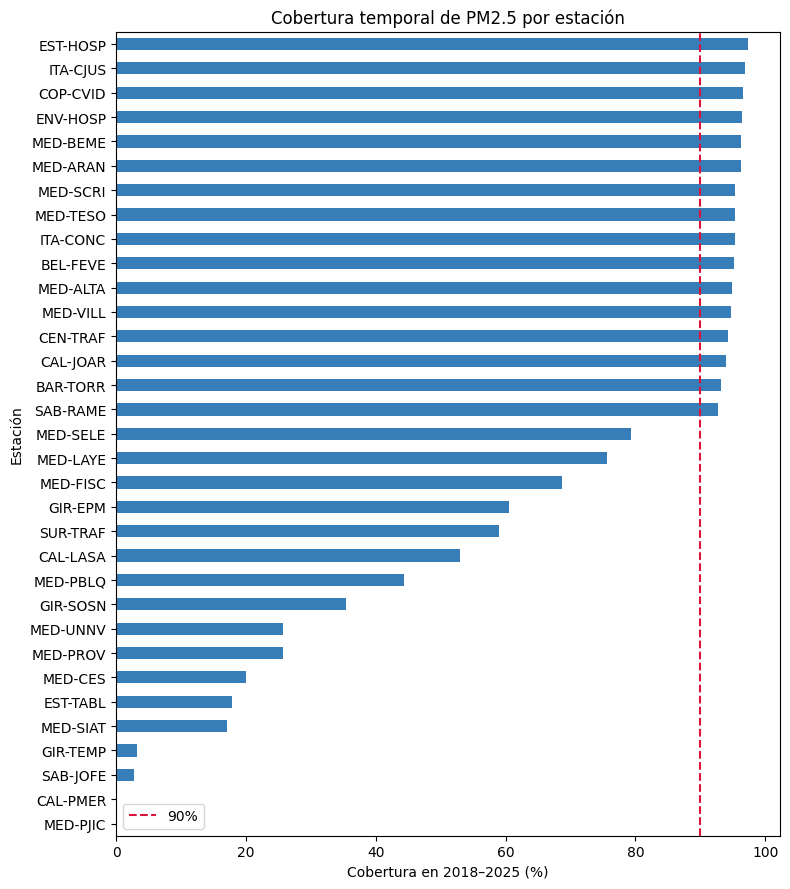

In [8]:
candidate_coverage.sort_values().plot.barh(figsize=(8, 9), color='#377eb8')
plt.axvline(90, color='crimson', linestyle='--', label='90%')
plt.xlabel('Cobertura en 2018–2025 (%)')
plt.ylabel('Estación')
plt.title('Cobertura temporal de PM2.5 por estación')
plt.legend()
plt.tight_layout()
plt.show()

La línea roja marca el criterio de 90%. Se conservaron 16 estaciones, con coberturas entre 92,67% y 97,41%. El filtro evita comparar series con periodos muy distintos y deja explícito cuánta información aporta cada estación.

## 6. Variable objetivo y tabla analítica

En formato largo, cada fila es una **estación en una hora**: `pm25` es la medición de la hora `t`, `station_id` identifica dónde fue tomada y `fecha_hora` permite ordenar la serie y crear variables temporales. Esta tabla horaria se conserva para describir la distribución y los patrones intradiarios.

La unidad de la pregunta de investigación es la **estación-día**. `pm25_mean` es la media de PM2.5 del día calendario, calculada solo cuando hay al menos 18 horas válidas (75% del día). El target `pm25_mean_d_plus_1` es la media de la misma estación el día calendario siguiente. La media de 24 horas es la unidad que la Resolución 2254 de 2017 usa para los niveles de prevención, alerta y emergencia, y un día es un horizonte con margen para decisiones preventivas.


In [9]:
selected_stations = candidate_coverage[candidate_coverage >= 90].index.tolist()
analysis_wide = candidate[['fecha_hora', *selected_stations]].copy()
analysis_long = analysis_wide.melt(
    id_vars='fecha_hora',
    var_name='station_id',
    value_name='pm25',
).sort_values(['station_id', 'fecha_hora'])

analysis_long['hour'] = analysis_long['fecha_hora'].dt.hour
analysis_long['day_of_week'] = analysis_long['fecha_hora'].dt.dayofweek
analysis_long['month'] = analysis_long['fecha_hora'].dt.month
analysis_long['date'] = analysis_long['fecha_hora'].dt.floor('D')

MIN_HOURS_PER_DAY = 18
daily = (
    analysis_long.groupby(['station_id', 'date'])['pm25']
    .agg(pm25_mean='mean', valid_hours='count')
    .reset_index()
    .sort_values(['station_id', 'date'])
)
daily.loc[daily['valid_hours'] < MIN_HOURS_PER_DAY, 'pm25_mean'] = np.nan
next_mean = daily.groupby('station_id')['pm25_mean'].shift(-1)
next_date = daily.groupby('station_id')['date'].shift(-1)
daily['pm25_mean_d_plus_1'] = next_mean.where(next_date - daily['date'] == pd.Timedelta(days=1))
daily['year'] = daily['date'].dt.year
daily['month'] = daily['date'].dt.month
daily['day_of_week'] = daily['date'].dt.dayofweek

display(daily.head())
print('Shape ancho (hora × estaciones):', analysis_wide.shape)
print('Shape largo (estación-hora):', analysis_long.shape)
print('Shape diario (estación-día):', daily.shape)
print('Días-estación con al menos 18 horas válidas:', int(daily['pm25_mean'].notna().sum()))
supervised = daily.dropna(subset=['pm25_mean', 'pm25_mean_d_plus_1']).copy()
print('Registros con media de hoy y target de mañana:', len(supervised))
print('Porcentaje utilizable:', round(100 * len(supervised) / len(daily), 2), '%')


,station_id,date,pm25_mean,valid_hours,pm25_mean_d_plus_1,year,month,day_of_week
0,BAR-TORR,2018-01-01,17.831593,23,13.014660,2018,1,0
1,BAR-TORR,2018-01-02,13.014660,23,12.264085,2018,1,1
2,BAR-TORR,2018-01-03,12.264085,23,10.933441,2018,1,2
3,BAR-TORR,2018-01-04,10.933441,24,16.933715,2018,1,3
4,BAR-TORR,2018-01-05,16.933715,24,13.421844,2018,1,4


Shape ancho (hora × estaciones): (70128, 17)
Shape largo (estación-hora): (1122048, 7)
Shape diario (estación-día): (46752, 8)
Días-estación con al menos 18 horas válidas: 45152
Registros con media de hoy y target de mañana: 44399
Porcentaje utilizable: 94.97 %


`valid_hours` documenta cuántas horas respaldan cada media diaria. De las 46.752 combinaciones estación-día de la ventana, 45.152 tienen al menos 18 horas válidas y 44.399 (94,97%) cuentan además con la media del día siguiente; esa es la tabla supervisada. `pm25_mean_d_plus_1` es una variable numérica continua, por lo que el problema es de **regresión supervisada**. El target nunca debe incluirse entre las variables de entrada, y ninguna variable del día siguiente puede usarse como predictor.


,pm25_mean_d_plus_1
count,44399.00
mean,17.89
std,7.75
min,2.04
1%,6.48
25%,12.69
50%,16.33
75%,21.22
95%,32.57
99%,45.19


Límite superior IQR del target diario: 34.02 µg/m³
Registros por encima del límite IQR: 1852 (4.17 %)
Registros con target >= 38 µg/m³: 1090 (2.46 %)
Días-estación sin media por tener menos de 18 horas válidas: 1600


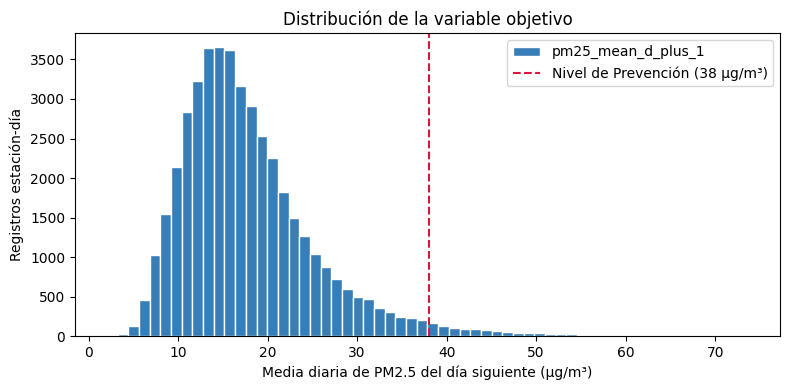

In [10]:
target = supervised['pm25_mean_d_plus_1']
display(target.describe(percentiles=[0.01, 0.25, 0.50, 0.75, 0.95, 0.99]).round(2).to_frame('pm25_mean_d_plus_1'))
q1_d, q3_d = target.quantile([0.25, 0.75])
iqr_d = q3_d - q1_d
upper_d = q3_d + 1.5 * iqr_d
print('Límite superior IQR del target diario:', round(upper_d, 2), 'µg/m³')
print('Registros por encima del límite IQR:', int((target > upper_d).sum()), f'({100 * (target > upper_d).mean():.2f} %)')
print('Registros con target >= 38 µg/m³:', int((target >= 38).sum()), f'({100 * (target >= 38).mean():.2f} %)')
print('Días-estación sin media por tener menos de 18 horas válidas:', int(daily['pm25_mean'].isna().sum()))

target.plot.hist(bins=60, figsize=(8, 4), color='#377eb8', edgecolor='white')
plt.axvline(38, color='crimson', linestyle='--', label='Nivel de Prevención (38 µg/m³)')
plt.xlabel('Media diaria de PM2.5 del día siguiente (µg/m³)')
plt.ylabel('Registros estación-día')
plt.title('Distribución de la variable objetivo')
plt.legend()
plt.tight_layout()
plt.show()


La media diaria del día siguiente tiene media de 17,89 µg/m³, mediana de 16,33 µg/m³ y desviación estándar de 7,75 µg/m³, con un rango de 2,04 a 73,67 µg/m³. La distribución es asimétrica a la derecha: 1.852 registros (4,17%) superan el límite IQR de 34,02 µg/m³ y 1.090 (2,46%) alcanzan el Nivel de Prevención. Esos valores altos no se eliminan porque son precisamente los episodios que interesa anticipar; el desbalance entre días normales y días en prevención condiciona la evaluación de la Entrega 2. De los 46.752 días-estación de la ventana, 1.600 (3,4%) no reciben media por tener menos de 18 horas válidas.


## 7. Decisiones de limpieza

- Los 162 archivos de `data/raw/pm25` no se modifican.
- No hay duplicados que eliminar.
- Los faltantes se conservan para describir cobertura. Un día calendario solo recibe media si tiene al menos 18 horas válidas; para la tabla supervisada se excluyen los registros sin media de hoy o sin media de mañana. No se imputa.
- Los ceros y posibles outliers se conservan porque no existe evidencia suficiente para declararlos errores.
- La selección de 16 estaciones se basa únicamente en cobertura ≥90% durante 2018–2025.

Estas reglas separan limpieza de transformación: pasar de ancho a largo, agregar por día y crear el target no altera las mediciones originales.

## 8. Distribución y valores extremos

Se describen únicamente mediciones horarias presentes. Los valores extremos se identifican con el criterio del rango intercuartílico (IQR), pero no se eliminan: una concentración alta puede representar un episodio real de contaminación.


In [11]:
observed = analysis_long.dropna(subset=['pm25']).copy()
display(observed['pm25'].describe(percentiles=[0.01, 0.25, 0.50, 0.75, 0.95, 0.99]).to_frame())
q1, q3 = observed['pm25'].quantile([0.25, 0.75])
iqr = q3 - q1
lower_bound, upper_bound = q1 - 1.5 * iqr, q3 + 1.5 * iqr
potential_outliers = ~observed['pm25'].between(lower_bound, upper_bound)
print('Límites IQR:', round(lower_bound, 2), round(upper_bound, 2))
print('Valores fuera de los límites:', int(potential_outliers.sum()))

,pm25
count,1.069236e+06
mean,1.792245e+01
std,1.089151e+01
min,0.000000e+00
1%,1.192074e+00
25%,1.043988e+01
50%,1.600000e+01
75%,2.305692e+01
95%,3.840212e+01
99%,5.315233e+01


Límites IQR: -8.49 41.98
Valores fuera de los límites: 37083


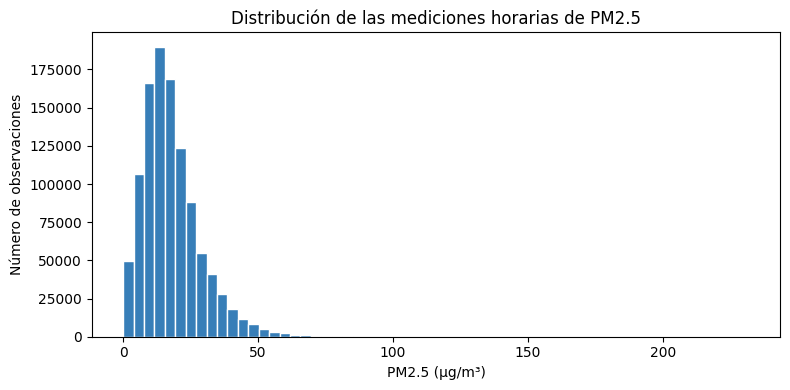

In [12]:
observed['pm25'].plot.hist(bins=60, figsize=(8, 4), color='#377eb8', edgecolor='white')
plt.xlabel('PM2.5 (µg/m³)')
plt.ylabel('Número de observaciones')
plt.title('Distribución de las mediciones horarias de PM2.5')
plt.tight_layout()
plt.show()

La distribución es asimétrica a la derecha: la mediana es 16,00 µg/m³, la media 17,92 µg/m³ y el percentil 99 es 53,15 µg/m³. El criterio IQR marca 37.083 observaciones (3,47%) por encima de 41,98 µg/m³. Se conservan porque pueden corresponder a episodios reales y no a errores de medición. Los 2.747 ceros (0,26%) también se conservan: SIATA reporta mínimos horarios de 0,0 y no se identificó un código sentinela cero.

## 9. Patrones temporales

Se calculan promedios por hora del día y por mes. Estas agrupaciones describen patrones; no demuestran causalidad ni sustituyen la validación temporal del modelo.

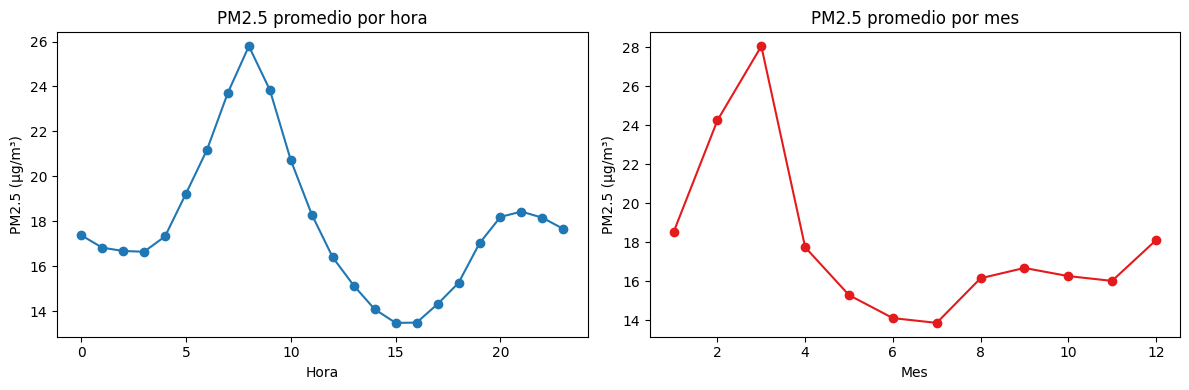

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
observed.groupby('hour')['pm25'].mean().plot(ax=axes[0], marker='o')
axes[0].set(title='PM2.5 promedio por hora', xlabel='Hora', ylabel='PM2.5 (µg/m³)')
observed.groupby('month')['pm25'].mean().plot(ax=axes[1], marker='o', color='#e41a1c')
axes[1].set(title='PM2.5 promedio por mes', xlabel='Mes', ylabel='PM2.5 (µg/m³)')
plt.tight_layout()
plt.show()

El promedio horario alcanza su máximo a las 08:00 (25,79 µg/m³) y su mínimo a las 15:00 (13,48 µg/m³). Por mes, marzo presenta el mayor promedio (28,05 µg/m³) y julio el menor (13,87 µg/m³). Estos patrones justifican evaluar hora y mes como predictores, pero describen asociación temporal y no causalidad.

## 10. Diferencias entre estaciones

Se comparan conteo, media y mediana dentro de la misma ventana temporal. La estación identifica el lugar de medición y puede capturar diferencias espaciales, de entorno y de exposición a fuentes locales.

,count,mean,median
station_id,,,
BAR-TORR,65332,12.67,10.59
COP-CVID,67765,14.27,12.73
BEL-FEVE,66798,14.95,13.21
MED-SCRI,66863,15.84,14.51
ENV-HOSP,67577,16.00,14.31
MED-TESO,66856,16.38,14.72
SAB-RAME,64985,17.13,15.45
MED-VILL,66415,17.30,15.59
EST-HOSP,68314,17.53,16.00


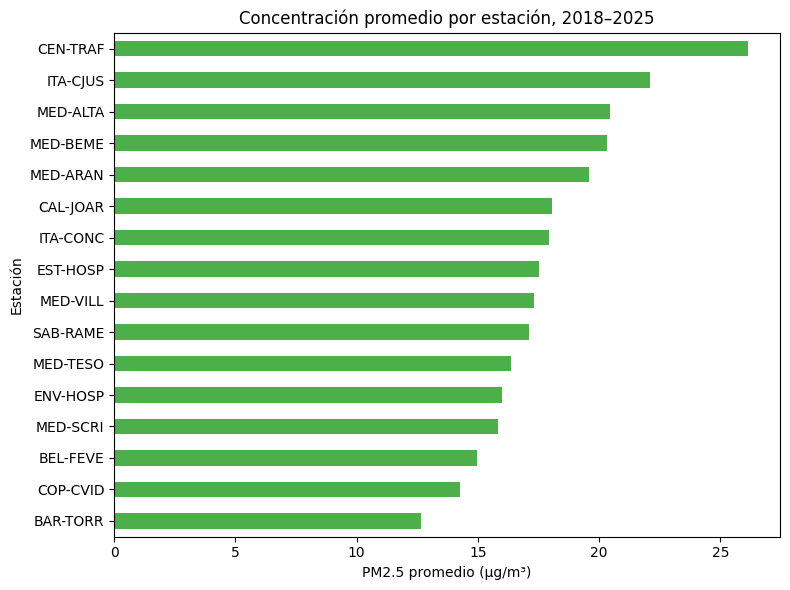

In [14]:
station_summary = observed.groupby('station_id')['pm25'].agg(['count', 'mean', 'median']).sort_values('mean')
display(station_summary.round(2))
station_summary['mean'].plot.barh(figsize=(8, 6), color='#4daf4a')
plt.xlabel('PM2.5 promedio (µg/m³)')
plt.ylabel('Estación')
plt.title('Concentración promedio por estación, 2018–2025')
plt.tight_layout()
plt.show()

CEN-TRAF presenta el promedio más alto (26,16 µg/m³) y BAR-TORR el más bajo (12,67 µg/m³). La diferencia confirma que `station_id` contiene información relevante. No implica que la ubicación sea la causa única: la emisión local, meteorología y tipo de entorno no se modelan en esta entrega.

## 11. Persistencia diaria y días en Nivel de Prevención

La Resolución 2254 de 2017 fija el **Nivel de Prevención** para PM2.5 en una media de 24 horas de 38 a 55 µg/m³ (Tabla 4) y exige evaluarlo por punto de monitoreo. Aquí se cuantifican tres cosas que la Entrega 2 necesita: cuánta señal tiene la persistencia diaria (predecir que mañana será igual a hoy), cuántos días-estación alcanzan el nivel de prevención cada año y cuántos de ellos son **inicios de episodio** (el día anterior no estaba en prevención). Con el umbral de 38 µg/m³ la persistencia no anticipa ningún inicio, pero como los episodios suben de forma gradual, una regla de persistencia con umbral de aviso más bajo sí captura muchos; por eso la comparación justa entre modelos y persistencia debe hacerse con el mismo número de avisos.


Correlación media diaria hoy vs mañana: 0.805
MAE del baseline de persistencia diaria: 3.58 µg/m³


,dias_estacion,en_prevencion,inicios_episodio,pct_en_prevencion
year,,,,
2018,5477,140,73,2.56
2019,5698,255,128,4.48
2020,5677,412,89,7.26
2021,5607,26,25,0.46
2022,5546,59,30,1.06
2023,5465,36,26,0.66
2024,5520,158,63,2.86
2025,5409,4,4,0.07


Días-estación en prevención (mañana): 1090 (2.46 % de los registros)
Inicios de episodio: 438 (40.2 % de los eventos)
Persistencia como aviso de prevención: precisión 0.6 | recall 0.6


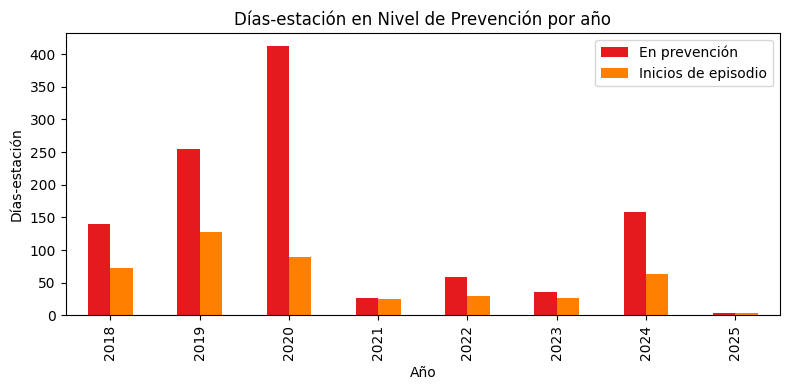

In [15]:
PREVENTION_THRESHOLD = 38.0  # Nivel de Prevención PM2.5 24 h, Resolución 2254 de 2017, Tabla 4

daily_correlation = supervised['pm25_mean'].corr(supervised['pm25_mean_d_plus_1'])
persistence_mae = (supervised['pm25_mean_d_plus_1'] - supervised['pm25_mean']).abs().mean()
print('Correlación media diaria hoy vs mañana:', round(daily_correlation, 3))
print('MAE del baseline de persistencia diaria:', round(persistence_mae, 2), 'µg/m³')

supervised['prevencion_hoy'] = supervised['pm25_mean'] >= PREVENTION_THRESHOLD
supervised['prevencion_manana'] = supervised['pm25_mean_d_plus_1'] >= PREVENTION_THRESHOLD
supervised['inicio_episodio'] = ~supervised['prevencion_hoy'] & supervised['prevencion_manana']

events_by_year = supervised.groupby('year').agg(
    dias_estacion=('pm25_mean_d_plus_1', 'size'),
    en_prevencion=('prevencion_manana', 'sum'),
    inicios_episodio=('inicio_episodio', 'sum'),
)
events_by_year['pct_en_prevencion'] = (100 * events_by_year['en_prevencion'] / events_by_year['dias_estacion']).round(2)
display(events_by_year)

total_events = int(supervised['prevencion_manana'].sum())
total_starts = int(supervised['inicio_episodio'].sum())
true_pos = int((supervised['prevencion_hoy'] & supervised['prevencion_manana']).sum())
false_pos = int((supervised['prevencion_hoy'] & ~supervised['prevencion_manana']).sum())
false_neg = int((~supervised['prevencion_hoy'] & supervised['prevencion_manana']).sum())
print('Días-estación en prevención (mañana):', total_events, f'({100 * total_events / len(supervised):.2f} % de los registros)')
print('Inicios de episodio:', total_starts, f'({100 * total_starts / total_events:.1f} % de los eventos)')
print('Persistencia como aviso de prevención: precisión', round(true_pos / (true_pos + false_pos), 2), '| recall', round(true_pos / (true_pos + false_neg), 2))

fig, ax = plt.subplots(figsize=(8, 4))
events_by_year[['en_prevencion', 'inicios_episodio']].plot.bar(ax=ax, color=['#e41a1c', '#ff7f00'])
ax.set(title='Días-estación en Nivel de Prevención por año', xlabel='Año', ylabel='Días-estación')
ax.legend(['En prevención', 'Inicios de episodio'])
plt.tight_layout()
plt.show()


La media diaria de hoy y la de mañana tienen correlación 0,805, y repetir la media de hoy como pronóstico de mañana da un MAE de 3,58 µg/m³: la persistencia diaria es un baseline exigente que cualquier modelo deberá superar sobre un periodo de prueba futuro.

En 2018–2025 hay 1.090 días-estación en Nivel de Prevención (2,46% de los registros), muy desiguales entre años: 412 en 2020 y solo 4 en 2025. De esos eventos, 438 (40,2%) son inicios de episodio. Usada como aviso de "mañana en prevención", la persistencia obtiene precisión y recall de 0,60, porque los episodios duran varios días; con umbral 38 no anticipa ningún inicio. Eso no significa que los inicios sean imprevisibles: el día previo a un inicio el PM2.5 ya suele estar elevado, de modo que una persistencia con umbral de aviso más bajo también los captura, a costa de más falsas alarmas. Dos consecuencias para la Entrega 2: la evaluación no puede apoyarse en un único año de prueba (2025 casi no tiene eventos) y el aporte de un modelo en los inicios de episodio debe medirse frente a la persistencia con el mismo número de avisos (igual precisión o igual presupuesto de alertas).


Días con al menos una estación en prevención: 246


,dias,pct
en_prevencion,,
1,110,44.7
2–3,46,18.7
4–6,33,13.4
7–10,17,6.9
11–16,40,16.3


Días de evento con tres estaciones o menos: 156
Días de evento en febrero y marzo: 179


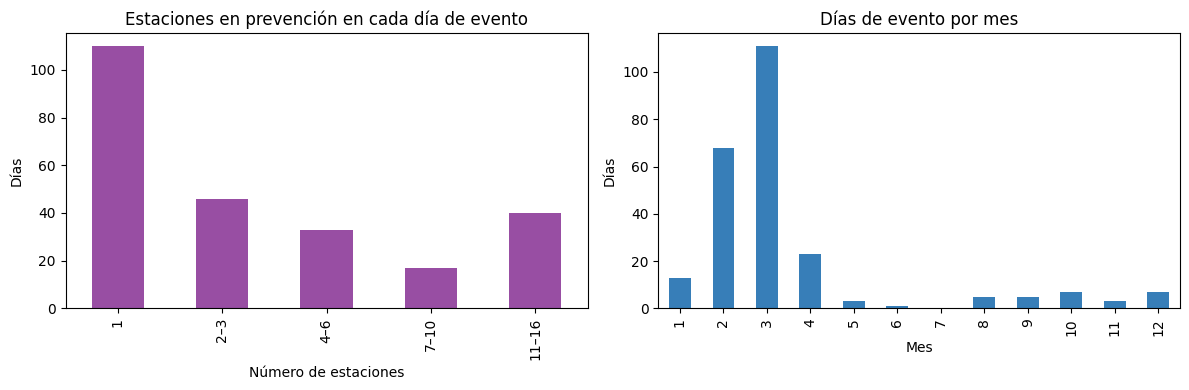

In [16]:
daily_valid = daily.dropna(subset=['pm25_mean']).copy()
daily_valid['en_prevencion'] = daily_valid['pm25_mean'] >= PREVENTION_THRESHOLD
by_day = daily_valid.groupby('date').agg(estaciones_validas=('en_prevencion', 'size'), en_prevencion=('en_prevencion', 'sum'))
event_days = by_day[by_day['en_prevencion'] > 0].copy()
print('Días con al menos una estación en prevención:', len(event_days))
spread = pd.cut(event_days['en_prevencion'], bins=[0, 1, 3, 6, 10, 16], labels=['1', '2–3', '4–6', '7–10', '11–16'])
spread_table = spread.value_counts().sort_index().to_frame('dias')
spread_table['pct'] = (100 * spread_table['dias'] / len(event_days)).round(1)
display(spread_table)
print('Días de evento con tres estaciones o menos:', int((event_days['en_prevencion'] <= 3).sum()))
event_months = event_days.index.month.value_counts().sort_index()
print('Días de evento en febrero y marzo:', int(event_months.reindex([2, 3], fill_value=0).sum()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
spread_table['dias'].plot.bar(ax=axes[0], color='#984ea3')
axes[0].set(title='Estaciones en prevención en cada día de evento', xlabel='Número de estaciones', ylabel='Días')
event_months.reindex(range(1, 13), fill_value=0).plot.bar(ax=axes[1], color='#377eb8')
axes[1].set(title='Días de evento por mes', xlabel='Mes', ylabel='Días')
plt.tight_layout()
plt.show()


En 246 días al menos una estación estuvo en Nivel de Prevención. En 110 de ellos (44,7%) fue una sola estación y en 156 (63,4%) fueron tres o menos; solo en 40 días el nivel abarcó más de diez estaciones. Los episodios son, en su mayoría, fenómenos locales, lo que respalda un pronóstico por estación frente a un aviso agregado para todo el valle. Además, 179 de los 246 días de evento ocurren en febrero y marzo, coherente con el máximo mensual observado en la sección 9.


## 12. Meteorología asignada a cada estación

A cada estación de PM2.5 se le asigna la estación meteorológica de SIATA más cercana instalada antes de 2018 (`src/data/stations.py`). La tabla siguiente reproduce la distancia con las coordenadas oficiales de ambas redes, descargadas a `data/raw/network/` por el script de descarga meteorológica.


In [17]:
air_stations = pd.read_csv(NETWORK_DIR / 'calidad_aire' / 'Estaciones_calidad_aire.tab').set_index('Nombre_Corto_Estacion')
meteo_stations = pd.read_csv(NETWORK_DIR / 'meteorologica' / 'Estaciones_meteorologica.tab').set_index('Código')


def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 2 * 6371 * np.arcsin(np.sqrt(a))


matching_rows = []
for station_id in selected_stations:
    meteo_code = PM25_TO_METEO[station_id]
    air, met = air_stations.loc[station_id], meteo_stations.loc[meteo_code]
    matching_rows.append({
        'station_id': station_id,
        'municipio': air['Municipio'].split(' - ')[0],
        'meteo_code': meteo_code,
        'meteo_nombre': met['Nombre'],
        'distancia_km': round(haversine_km(air['Latitud'], air['Longitud'], met['Latitud'], met['Longitud']), 1),
        'meteo_instalada': met['Fecha Instalación'],
    })
matching = pd.DataFrame(matching_rows).set_index('station_id')
display(matching)
print('Estaciones meteorológicas distintas:', matching['meteo_code'].nunique())
print('Estaciones PM2.5 con meteorología a 3 km o menos:', int((matching['distancia_km'] <= 3).sum()), 'de', len(matching))


,municipio,meteo_code,meteo_nombre,distancia_km,meteo_instalada
station_id,,,,,
EST-HOSP,La Estrella,229,Alcaldia La Estrella - Thies,0.4,2017-08-31
ITA-CJUS,Itagüí,252,Alcaldia Envigado - Meteorologica,2.0,2017-04-24
COP-CVID,Copacabana,73,Ciudadela Educativa La Vida,0.0,2013-05-24
ENV-HOSP,Envigado,252,Alcaldia Envigado - Meteorologica,0.7,2017-04-24
MED-BEME,Medellín,197,Universidad de Medellin - Meteorologica,1.4,2017-08-16
MED-ARAN,Medellín,68,Jardin Botanico - Meteorologica Vaisala,2.8,2013-02-01
MED-SCRI,Medellín,201,Torre SIATA,5.8,2012-12-28
MED-TESO,Medellín,59,ISAGEN,1.6,2013-04-12
ITA-CONC,Itagüí,206,Colegio Concejo de Itagui,0.1,2012-11-06


Estaciones meteorológicas distintas: 12
Estaciones PM2.5 con meteorología a 3 km o menos: 15 de 16


### 12.1 Cobertura horaria válida por variable

La tabla horaria ya descarta los minutos marcados como dudosos por la bandera `calidad` de SIATA y los faltantes `-999`, y exige 45 minutos válidos por hora. La cobertura se expresa como porcentaje de las horas de la ventana 2018–2025.


In [18]:
if not METEO_HOURLY.exists():
    raise FileNotFoundError('Ejecute python scripts/build_meteo_hourly.py antes de esta sección')
meteo_hourly = pd.read_csv(METEO_HOURLY, parse_dates=['fecha_hora'])
meteo_hourly = meteo_hourly[meteo_hourly['fecha_hora'].between('2018-01-01', '2025-12-31 23:00:00')]
METEO_VARIABLES = ['t', 'h', 'pr', 'vv', 'vv_max', 'dv', 'p']
expected_hours = len(candidate)
meteo_coverage = (meteo_hourly.groupby('codigo')[METEO_VARIABLES].count().div(expected_hours).mul(100)).round(1)
display(meteo_coverage)
print('Filas horarias:', len(meteo_hourly), '| horas esperadas por estación:', expected_hours)
display(meteo_hourly[METEO_VARIABLES].describe().round(2))


,t,h,pr,vv,vv_max,dv,p
codigo,,,,,,,
59,94.1,94.5,94.5,94.4,94.4,94.4,94.5
68,92.2,93.9,93.9,93.8,93.8,93.8,93.9
73,93.2,96.1,96.1,96.0,96.0,93.5,96.1
82,94.0,95.8,95.8,95.6,95.6,95.6,95.8
105,91.8,95.2,95.2,95.4,95.4,95.4,95.4
197,90.7,87.9,90.7,92.2,91.5,92.2,92.2
201,88.1,95.8,95.8,95.8,95.8,95.8,95.8
202,94.4,97.7,97.7,97.8,97.8,97.8,97.8
206,92.9,94.8,94.8,32.8,32.8,32.8,94.8


Filas horarias: 801839 | horas esperadas por estación: 70128


,t,h,pr,vv,vv_max,dv,p
count,771013.00,781780.00,730014.00,744518.00,741673.00,742714.00,775580.00
mean,21.12,73.53,842.41,1.68,4.60,147.32,0.25
std,3.35,16.56,14.20,1.05,2.54,106.90,1.54
min,10.84,10.99,0.00,0.16,0.60,0.00,0.00
25%,18.54,62.21,826.95,0.92,2.60,58.02,0.00
50%,20.51,77.41,847.20,1.35,4.00,118.21,0.00
75%,23.46,86.34,852.72,2.16,6.10,234.10,0.00
max,33.08,100.00,870.28,9.53,28.50,360.00,67.03


Once de las doce estaciones meteorológicas tienen entre 88% y 98% de horas válidas en casi todas las variables. Hay tres huecos estructurales que corresponden a sensores ausentes durante periodos largos: el viento de la estación 206 (32,8%, sin datos entre mediados de 2019 y mediados de 2024), la presión de la 252 (14,6%, sin datos desde 2019) y la precipitación de la 229 (74,3%, con faltantes en 2022–2024). La estación 271 termina en julio de 2024, lo que reduce todas sus variables a cerca de 79%. Las alternativas para cada hueco se documentan en `docs/station_matching.md` y se resolverán al construir los predictores. Los descriptivos son físicamente plausibles (temperatura media de 21,1 °C, humedad de 73,5%, viento medio de 1,7 m/s), aunque aparecen presiones de 0 hPa que la bandera de calidad no marcó y que deben validarse antes del modelado.


### 12.2 Relación descriptiva entre meteorología diaria y PM2.5

Para la pregunta de investigación las variables meteorológicas se usan como predictores observados hasta el final del día `d`. Como primera exploración se agrega la meteorología por día (media de `t`, `h`, `pr` y `vv`; máximo de `vv_max`; suma de `p`; al menos 18 horas válidas) y se calcula la correlación de Spearman (Pearson sobre rangos) con la media diaria de PM2.5 del mismo día y del día siguiente. Es una relación descriptiva, no una evaluación de modelos.


In [19]:
meteo_hourly['date'] = meteo_hourly['fecha_hora'].dt.floor('D')
agg = {'t': 'mean', 'h': 'mean', 'pr': 'mean', 'vv': 'mean', 'vv_max': 'max', 'p': 'sum'}
meteo_daily = meteo_hourly.groupby(['codigo', 'date']).agg(agg)
meteo_hours = meteo_hourly.groupby(['codigo', 'date'])[list(agg)].count()
meteo_daily = meteo_daily.where(meteo_hours >= MIN_HOURS_PER_DAY).reset_index()

joined = supervised.assign(codigo=supervised['station_id'].map(PM25_TO_METEO)).merge(meteo_daily, on=['codigo', 'date'], how='left')
print('Registros estación-día con meteorología completa del día:', int(joined[list(agg)].notna().all(axis=1).sum()), 'de', len(joined))
def spearman(x, y):
    mask = x.notna() & y.notna()
    return x[mask].rank().corr(y[mask].rank())


correlations = pd.DataFrame({
    'mismo_dia': [spearman(joined[v], joined['pm25_mean']) for v in agg],
    'dia_siguiente': [spearman(joined[v], joined['pm25_mean_d_plus_1']) for v in agg],
}, index=list(agg)).round(3)
display(correlations)


Registros estación-día con meteorología completa del día: 33134 de 44399


,mismo_dia,dia_siguiente
t,0.023,0.056
h,-0.027,-0.080
pr,-0.164,-0.163
vv,-0.122,-0.066
vv_max,-0.037,0.005
p,-0.124,-0.157


Con las 33.134 estaciones-día que tienen meteorología diaria completa, las correlaciones de rangos son débiles y con el signo esperado: más presión, más lluvia y más viento se asocian con menos PM2.5 al día siguiente (−0,16, −0,16 y −0,07, respectivamente). Una correlación agrupada entre todas las estaciones y estaciones del año es una medida gruesa: la relación es probablemente no lineal y depende de la temporada. Este resultado no anticipa el desempeño de un modelo; solo confirma que la meteorología del día contiene alguna información sobre el día siguiente que la persistencia no usa.


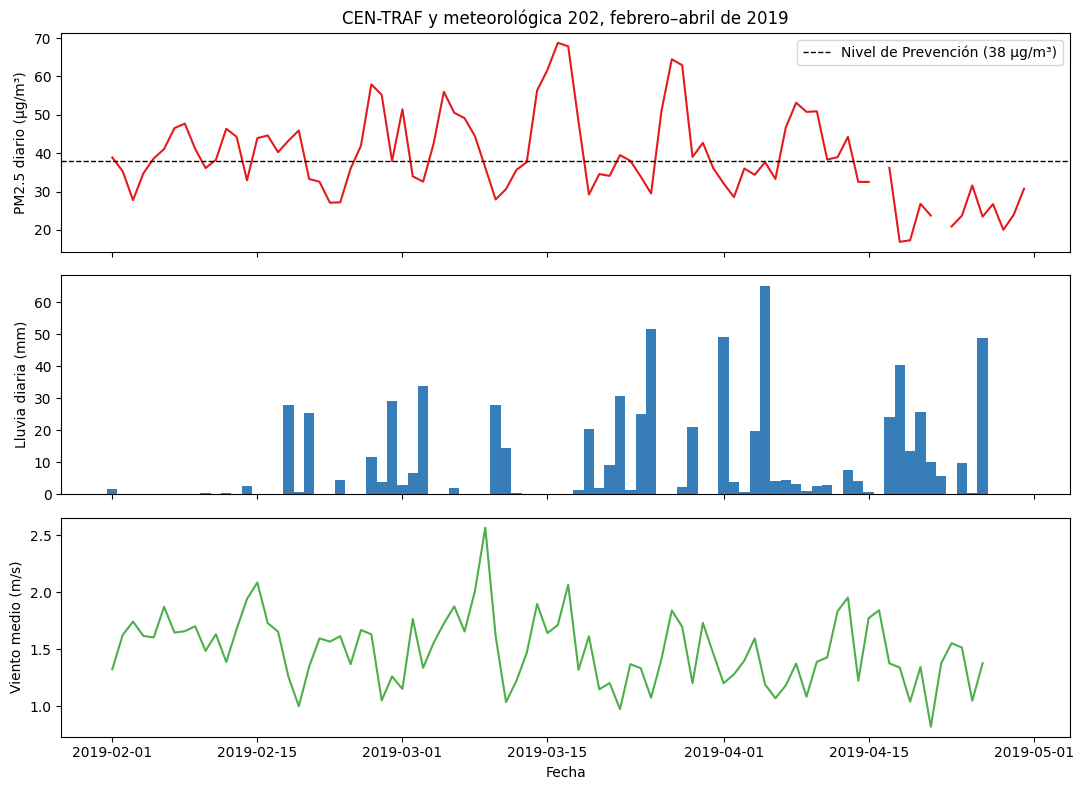

In [20]:
example_station, example_meteo = 'CEN-TRAF', PM25_TO_METEO['CEN-TRAF']
window = (pd.Timestamp('2019-02-01'), pd.Timestamp('2019-04-30'))
pm_example = daily[(daily['station_id'] == example_station) & daily['date'].between(*window)].set_index('date')
met_example = meteo_daily[(meteo_daily['codigo'] == example_meteo) & meteo_daily['date'].between(*window)].set_index('date')

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
axes[0].plot(pm_example.index, pm_example['pm25_mean'], color='#e41a1c')
axes[0].axhline(PREVENTION_THRESHOLD, color='black', linestyle='--', linewidth=1, label='Nivel de Prevención (38 µg/m³)')
axes[0].set(ylabel='PM2.5 diario (µg/m³)', title=f'{example_station} y meteorológica {example_meteo}, febrero–abril de 2019')
axes[0].legend(loc='upper right')
axes[1].bar(met_example.index, met_example['p'], color='#377eb8', width=1)
axes[1].set(ylabel='Lluvia diaria (mm)')
axes[2].plot(met_example.index, met_example['vv'], color='#4daf4a')
axes[2].set(ylabel='Viento medio (m/s)', xlabel='Fecha')
plt.tight_layout()
plt.show()


El episodio de febrero–abril de 2019 en CEN-TRAF ilustra el comportamiento típico: los picos por encima del Nivel de Prevención ocurren en rachas de varios días con lluvia escasa y viento medio bajo (entre 1 y 2 m/s), y la concentración cae tras los días de lluvia intensa de finales de marzo y de abril. La figura es descriptiva; no establece causalidad ni cuantifica cuánto anticiparía un modelo.


## 13. Hallazgos principales

Los tres hallazgos más útiles para el short paper son:

1. **Suficiencia y cobertura:** 16 estaciones alcanzan entre 92,67% y 97,41% de cobertura horaria en 2018–2025; agregadas por día quedan 44.399 registros estación-día con media de hoy y target de mañana. Quince de las 16 tienen una estación meteorológica de SIATA a 3 km o menos, con 88–98% de horas válidas en la mayoría de variables.
2. **Estructura temporal:** el promedio horario es máximo a las 08:00 (25,79 µg/m³) y mínimo a las 15:00 (13,48 µg/m³); marzo tiene el mayor promedio mensual (28,05 µg/m³) y 179 de los 246 días con alguna estación en Nivel de Prevención ocurren en febrero y marzo.
3. **Los episodios son locales y la persistencia es un rival exigente:** en 156 de los 246 días de evento (63,4%) tres estaciones o menos están en prevención, lo que justifica un pronóstico por estación. De los 1.090 días-estación en prevención, 438 (40,2%) son inicios de episodio; la persistencia diaria obtiene MAE de 3,58 µg/m³ y precisión y recall de 0,60 como aviso con umbral 38. Como los episodios suben gradualmente, el nivel de hoy ya anticipa buena parte de los inicios; el aporte de un modelo debe demostrarse con el mismo número de avisos que la persistencia.


## 14. Limitaciones

- La red cambió durante el histórico: existen 33 estaciones y 30 variantes de schema.
- La ventana y el umbral de cobertura reducen el análisis a 16 estaciones; los resultados no representan por igual toda la historia de la red.
- Los faltantes no se imputaron; un día sin 18 horas válidas no recibe media y la tabla supervisada excluye registros sin media de hoy o de mañana.
- Los ceros y valores extremos de PM2.5 se conservaron porque no hay evidencia suficiente para eliminarlos.
- La media del día calendario es una de las medias de 24 horas posibles; la norma usa medias móviles para constatación, por lo que el máximo de la media móvil del día se evaluará como sensibilidad.
- Los eventos de prevención son escasos (2,46%) y muy desiguales entre años; 2021, 2023 y 2025 aportan pocos casos.
- Dos estaciones tienen meteorología imperfecta: BEL-FEVE (estación 271 sin datos desde agosto de 2024) y MED-SCRI (estación 201 a 5,8 km). Hay huecos estructurales en el viento de 206, la presión de 252 y la lluvia de 229, y presiones de 0 hPa pendientes de validar.
- La zona horaria explícita no aparece en los metadatos consultados de ninguna de las dos redes.
- Las relaciones descritas entre meteorología y PM2.5 son correlaciones agrupadas; no se atribuyen causas.


## 15. Implicaciones para la pregunta de investigación

Los datos permiten formular empíricamente un problema supervisado de regresión para predecir `pm25_mean_d_plus_1` por estación, con predictores observados hasta el final del día anterior: historial de PM2.5, meteorología de la estación asignada y variables temporales. La cobertura, el volumen de registros y la disponibilidad de meteorología cercana indican que el modelado es viable. El EDA también fija las reglas de la evaluación: el baseline es la persistencia diaria (MAE 3,58 µg/m³; precisión y recall 0,60 como aviso de prevención), el aporte se mide sobre todo en los 438 inicios de episodio comparando con la persistencia a igual número de avisos, y la prueba debe cubrir varios años con origen móvil porque los eventos se concentran en 2018–2020 y 2024. Las correlaciones diarias débiles de la sección 12 anticipan que el aporte de la meteorología observada puede ser modesto; cuantificarlo es parte de la pregunta, y un aporte pequeño sería un resultado válido que señalaría la necesidad de pronóstico meteorológico. La Entrega 1 no demuestra todavía que un modelo supere ese baseline; esa comparación corresponde a la Entrega 2.


## 16. Reproducibilidad de las figuras del paper

Las dos figuras del short paper se regeneran y exportan a `paper/figuras/` desde esta celda, a partir de objetos ya calculados en el notebook (`target`, `spread_table` y `event_months`). Así, ejecutar el notebook reproduce exactamente los archivos que usa el documento.

In [21]:
FIGURES_DIR = PROJECT_ROOT / 'paper' / 'figuras'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Fig. 1 del paper: distribución de la variable objetivo
fig, ax = plt.subplots(figsize=(8, 4))
target.plot.hist(bins=60, ax=ax, color='#377eb8', edgecolor='white')
ax.axvline(38, color='crimson', linestyle='--', label='Nivel de Prevención (38 µg/m³)')
ax.set(xlabel='Media diaria de PM2.5 del día siguiente (µg/m³)',
       ylabel='Registros estación-día',
       title='Distribución de la variable objetivo')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'distribucion_target.png', dpi=100, bbox_inches='tight')
plt.close(fig)

# Fig. 2 del paper: extensión de los eventos de prevención
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
spread_table['dias'].plot.bar(ax=axes[0], color='#984ea3')
axes[0].set(title='Estaciones en prevención en cada día de evento',
            xlabel='Número de estaciones', ylabel='Días')
event_months.reindex(range(1, 13), fill_value=0).plot.bar(ax=axes[1], color='#377eb8')
axes[1].set(title='Días de evento por mes', xlabel='Mes', ylabel='Días')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'extension_eventos.png', dpi=100, bbox_inches='tight')
plt.close(fig)

print('Figuras exportadas a', FIGURES_DIR.relative_to(PROJECT_ROOT))

Figuras exportadas a paper/figuras
